## Customer Segmentation - Credit Cards
----------------------------------------------------------------------------------------------------------------------------------------

### About Dataset
This case requires to develop a customer segmentation to define marketing strategy. The sample Dataset summarizes the usage behavior of about 9000 active credit card holders during the last 6 months. The file is at a customer level with 18 behavioral variables.

Following is the Data Dictionary for Credit Card dataset :-

- CUST_ID : Identification of Credit Card holder (Categorical)
- BALANCE : Balance amount left in their account to make purchases 
- BALANCE_FREQUENCY : How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
- PURCHASES : Amount of purchases made from account
- ONEOFF_PURCHASES : Maximum purchase amount done in one-go
- INSTALLMENTS_PURCHASES : Amount of purchase done in installment
- CASH_ADVANCE : Cash in advance given by the user
- PURCHASES_FREQUENCY : How frequently the Purchases are being made, score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
- ONEOFFPURCHASESFREQUENCY : How frequently Purchases are happening in one-go (1 = frequently purchased, 0 = not frequently purchased)
- PURCHASESINSTALLMENTSFREQUENCY : How frequently purchases in installments are being done (1 = frequently done, 0 = not frequently done)
- CASHADVANCEFREQUENCY : How frequently the cash in advance being paid
- CASHADVANCETRX : Number of Transactions made with "Cash in Advanced"
- PURCHASES_TRX : Numbe of purchase transactions made
- CREDIT_LIMIT : Limit of Credit Card for user
- PAYMENTS : Amount of Payment done by user
- MINIMUM_PAYMENTS : Minimum amount of payments made by user
- PRCFULLPAYMENT : Percent of full payment paid by user
- TENURE : Tenure of credit card service for user

### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
import plotly.express as px
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser"

In [2]:
# libraries version
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Numpy version: 2.2.6
Pandas version: 2.3.3


In [3]:
pd.options.display.max_columns = 20
pd.options.display.max_rows = 100

## 1. Data Exploration

In [4]:
# Import dataset file & get pandas dataframe. also copy original dataframe for future reference.
df = pd.read_csv("../datasets/CC General.csv")
df_original = df.copy(deep=True)

In [5]:
# check total number of rows and columns in the dataset.
df.shape

(8950, 18)

In [6]:
# check dataset features
df.columns

Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES',
       'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
       'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY',
       'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS',
       'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

In [ ]:
# column renames

column_rename = {
    'CUST_ID': 'cust_id',
    'BALANCE': 'balance',
    'BALANCE_FREQUENCY': 'bal_freq',
    'PURCHASES': 'purch',
    'ONEOFF_PURCHASES': 'oneoff',
    'INSTALLMENTS_PURCHASES': 'install',
    'CASH_ADVANCE': 'cash_adv',
    'PURCHASES_FREQUENCY': 'purch_freq',
    'ONEOFF_PURCHASES_FREQUENCY': 'oneoff_freq',
    'PURCHASES_INSTALLMENTS_FREQUENCY': 'install_freq',
    'CASH_ADVANCE_FREQUENCY': 'cash_freq',
    'CASH_ADVANCE_TRX': 'cash_tx',
    'PURCHASES_TRX': 'purch_tx',
    'CREDIT_LIMIT': 'credit',
    'PAYMENTS': 'pay_amt',
    'MINIMUM_PAYMENTS': 'min_pay',
    'PRC_FULL_PAYMENT': 'full_pay',
    'TENURE': 'months'
}
df.rename(columns = column_rename, inplace = True)
df.head()

,cust_id,balance,bal_freq,purch,oneoff,install,cash_adv,purch_freq,oneoff_freq,install_freq,cash_freq,cash_tx,purch_tx,credit,pay_amt,min_pay,full_pay,months
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [8]:
# check top 5 rows of the dataset.
df.head()

,cust_id,balance,bal_freq,purch,oneoff,install,cash_adv,purch_freq,oneoff_freq,install_freq,cash_freq,cash_tx,purch_tx,credit,pay_amt,min_pay,full_pay,months
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [9]:
# check bottom 5 rows of the dataset.
df.tail()

,cust_id,balance,bal_freq,purch,oneoff,install,cash_adv,purch_freq,oneoff_freq,install_freq,cash_freq,cash_tx,purch_tx,credit,pay_amt,min_pay,full_pay,months
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.50,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.00,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.25,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.25,6
8949,C19190,372.708075,0.666667,1093.25,1093.25,0.00,127.040008,0.666667,0.666667,0.000000,0.333333,2,23,1200.0,63.165404,88.288956,0.00,6


In [10]:
# check random 10 rows of the dataset.
df.sample(10)

,cust_id,balance,bal_freq,purch,oneoff,install,cash_adv,purch_freq,oneoff_freq,install_freq,cash_freq,cash_tx,purch_tx,credit,pay_amt,min_pay,full_pay,months
5630,C15787,907.371097,1.000000,55.65,0.00,55.65,0.000000,0.166667,0.000000,0.166667,0.000000,0,3,1000.0,416.818116,603.735158,0.000000,12
704,C10731,963.572006,1.000000,2210.97,1741.30,469.67,0.000000,1.000000,1.000000,0.416667,0.000000,0,50,9500.0,2946.752322,345.153590,0.000000,12
2415,C12488,35.360897,1.000000,587.34,0.00,587.34,0.000000,1.000000,0.000000,1.000000,0.000000,0,14,11500.0,549.036894,139.958805,0.888889,12
5072,C15215,74.755978,1.000000,553.70,248.70,305.00,0.000000,0.583333,0.333333,0.166667,0.000000,0,9,1000.0,467.131192,169.840535,0.200000,12
1319,C11364,3661.051976,1.000000,764.00,515.45,248.55,1203.317833,0.166667,0.166667,0.166667,0.250000,3,13,9000.0,872.241096,985.784518,0.000000,12
1651,C11705,10.703306,0.090909,0.00,0.00,0.00,575.193978,0.000000,0.000000,0.000000,0.083333,1,0,1000.0,0.000000,NaN,0.000000,12
5366,C15519,1184.971992,1.000000,0.00,0.00,0.00,4743.715012,0.000000,0.000000,0.000000,0.500000,10,0,3000.0,2355.267462,268.140818,0.000000,12
2109,C12175,231.995439,1.000000,2310.21,1660.51,649.70,0.000000,1.000000,1.000000,0.916667,0.000000,0,67,3000.0,1871.658725,173.610118,0.727273,12
4489,C14614,7287.084204,1.000000,0.00,0.00,0.00,6605.075695,0.000000,0.000000,0.000000,0.750000,24,0,7500.0,4293.062891,5255.006819,0.000000,12
2651,C12728,1517.559661,1.000000,0.00,0.00,0.00,456.396077,0.000000,0.000000,0.000000,0.166667,2,0,1950.0,473.175712,381.272303,0.000000,12


In [11]:
# check dataset information.
df.info()

# --------------------------------------------------------------------
# Observations:
# Dataset has 8950 rows and 18 columns. 
# All columns are of numeric type except CUST_ID.
# There are null values in CREDIT_LIMIT, MINIMUM_PAYMENTS.
# --------------------------------------------------------------------


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cust_id       8950 non-null   object 
 1   balance       8950 non-null   float64
 2   bal_freq      8950 non-null   float64
 3   purch         8950 non-null   float64
 4   oneoff        8950 non-null   float64
 5   install       8950 non-null   float64
 6   cash_adv      8950 non-null   float64
 7   purch_freq    8950 non-null   float64
 8   oneoff_freq   8950 non-null   float64
 9   install_freq  8950 non-null   float64
 10  cash_freq     8950 non-null   float64
 11  cash_tx       8950 non-null   int64  
 12  purch_tx      8950 non-null   int64  
 13  credit        8949 non-null   float64
 14  pay_amt       8950 non-null   float64
 15  min_pay       8637 non-null   float64
 16  full_pay      8950 non-null   float64
 17  months        8950 non-null   int64  
dtypes: float64(14), int64(3), ob

In [12]:
# Checking number of unique rows in each feature
df.nunique().sort_values()

months             7
bal_freq          43
install_freq      47
purch_freq        47
full_pay          47
oneoff_freq       47
cash_freq         54
cash_tx           65
purch_tx         173
credit           205
oneoff          4014
cash_adv        4323
install         4452
purch           6203
min_pay         8636
pay_amt         8711
balance         8871
cust_id         8950
dtype: int64

In [13]:
nvc = pd.DataFrame(df.isnull().sum().sort_values(), columns=['Total Null Values'])
nvc['Percentage'] = round(nvc['Total Null Values']/df.shape[0],3)*100
print(nvc)

              Total Null Values  Percentage
cust_id                       0         0.0
balance                       0         0.0
bal_freq                      0         0.0
purch                         0         0.0
oneoff                        0         0.0
install                       0         0.0
cash_adv                      0         0.0
purch_freq                    0         0.0
oneoff_freq                   0         0.0
install_freq                  0         0.0
cash_freq                     0         0.0
cash_tx                       0         0.0
purch_tx                      0         0.0
pay_amt                       0         0.0
months                        0         0.0
full_pay                      0         0.0
credit                        1         0.0
min_pay                     313         3.5


In [14]:
# check duplicate values in the dataset.
df.duplicated().sum()

np.int64(0)

In [15]:
# check statistical summary of the dataset.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
balance,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
bal_freq,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
purch,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
oneoff,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
install,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
cash_adv,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
purch_freq,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
oneoff_freq,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
install_freq,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
cash_freq,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


## 2. Exploratory Data Analysis

In [16]:
df.columns

Index(['cust_id', 'balance', 'bal_freq', 'purch', 'oneoff', 'install',
       'cash_adv', 'purch_freq', 'oneoff_freq', 'install_freq', 'cash_freq',
       'cash_tx', 'purch_tx', 'credit', 'pay_amt', 'min_pay', 'full_pay',
       'months'],
      dtype='object')

In [17]:
def num_univariate(df, col):
    print("-"*100)
    print(f"Feature Name: {col}")
    print(("\nDescrtiptive Statistics:"))
    print(df[col].describe())
    print(f"\nSkewness: {np.round(df[col].skew(), 2)}")

    fig, ax = plt.subplots(2, 1, figsize=(10,6), sharex=True)
    sns.histplot(df, x=col, kde=True, ax=ax[0])
    sns.boxplot(df, x=col, ax=ax[1])

    ax[0].set_title(f"Distribution of {col}")
    
    plt.tight_layout()
    plt.show()

----------------------------------------------------------------------------------------------------
Feature Name: balance

Descrtiptive Statistics:
count     8950.000000
mean      1564.474828
std       2081.531879
min          0.000000
25%        128.281915
50%        873.385231
75%       2054.140036
max      19043.138560
Name: balance, dtype: float64

Skewness: 2.39


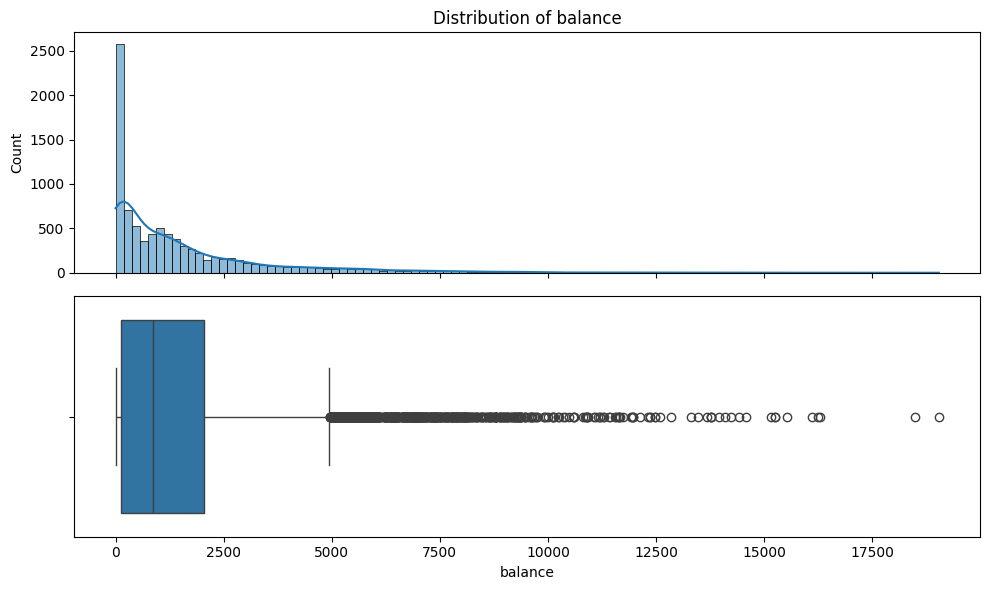

----------------------------------------------------------------------------------------------------
Feature Name: bal_freq

Descrtiptive Statistics:
count    8950.000000
mean        0.877271
std         0.236904
min         0.000000
25%         0.888889
50%         1.000000
75%         1.000000
max         1.000000
Name: bal_freq, dtype: float64

Skewness: -2.02


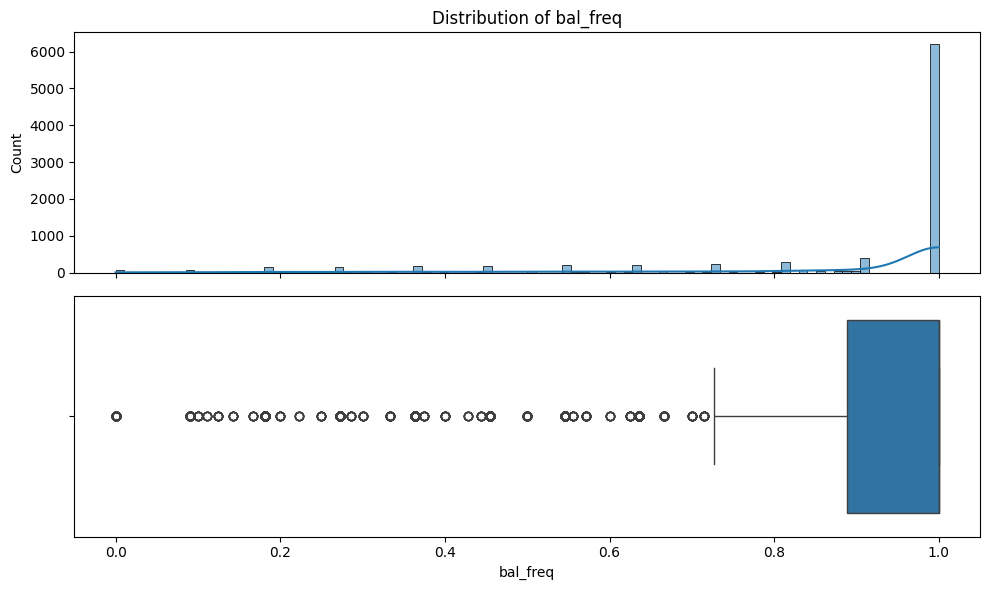

----------------------------------------------------------------------------------------------------
Feature Name: purch

Descrtiptive Statistics:
count     8950.000000
mean      1003.204834
std       2136.634782
min          0.000000
25%         39.635000
50%        361.280000
75%       1110.130000
max      49039.570000
Name: purch, dtype: float64

Skewness: 8.14


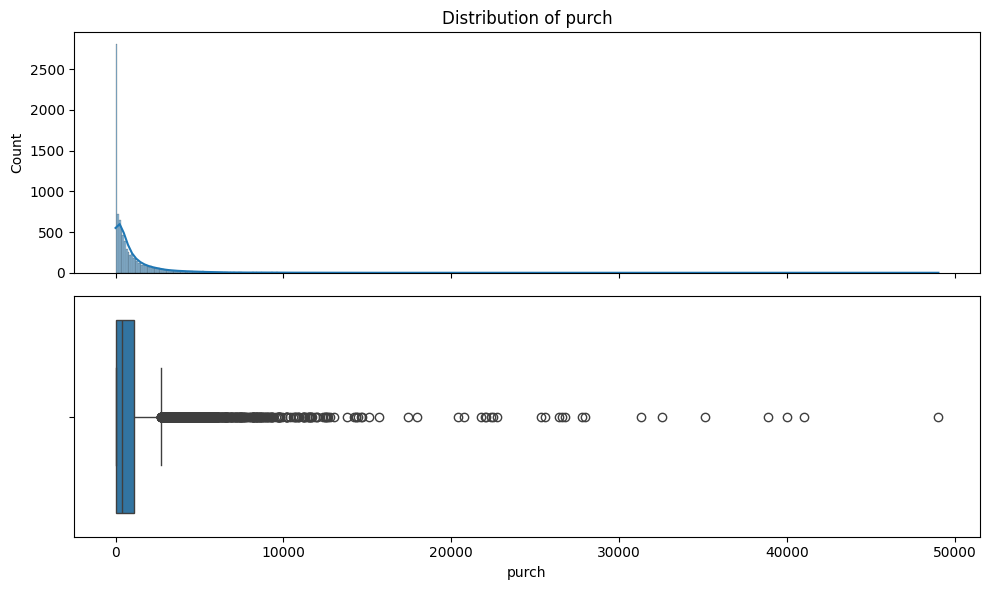

----------------------------------------------------------------------------------------------------
Feature Name: oneoff

Descrtiptive Statistics:
count     8950.000000
mean       592.437371
std       1659.887917
min          0.000000
25%          0.000000
50%         38.000000
75%        577.405000
max      40761.250000
Name: oneoff, dtype: float64

Skewness: 10.05


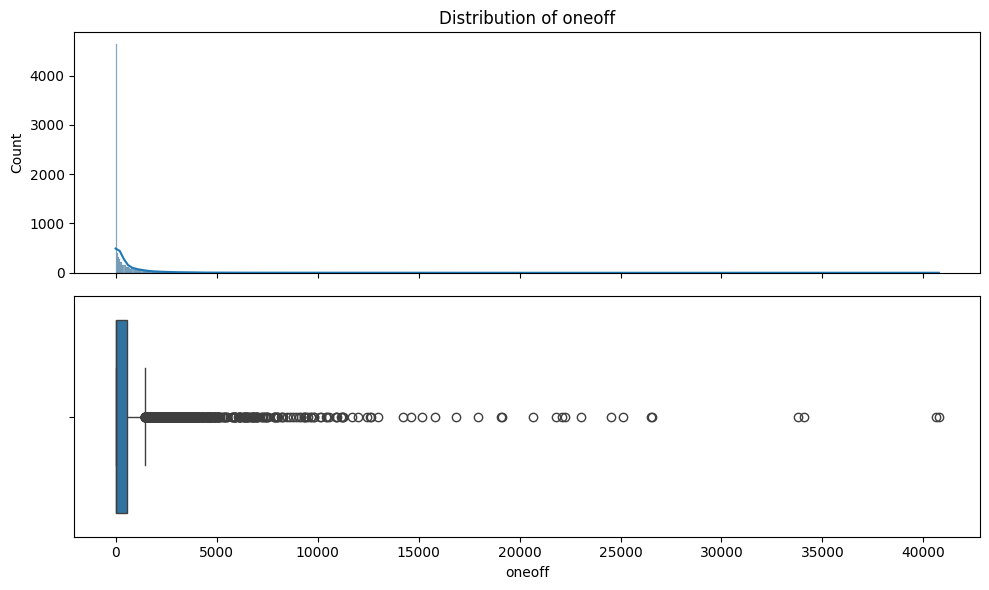

----------------------------------------------------------------------------------------------------
Feature Name: install

Descrtiptive Statistics:
count     8950.000000
mean       411.067645
std        904.338115
min          0.000000
25%          0.000000
50%         89.000000
75%        468.637500
max      22500.000000
Name: install, dtype: float64

Skewness: 7.3


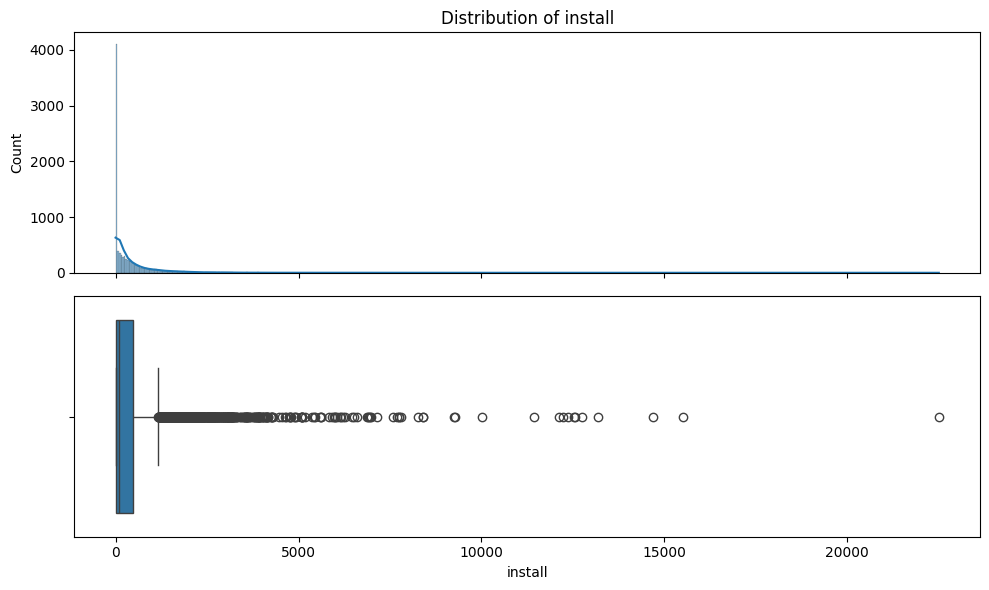

----------------------------------------------------------------------------------------------------
Feature Name: cash_adv

Descrtiptive Statistics:
count     8950.000000
mean       978.871112
std       2097.163877
min          0.000000
25%          0.000000
50%          0.000000
75%       1113.821139
max      47137.211760
Name: cash_adv, dtype: float64

Skewness: 5.17


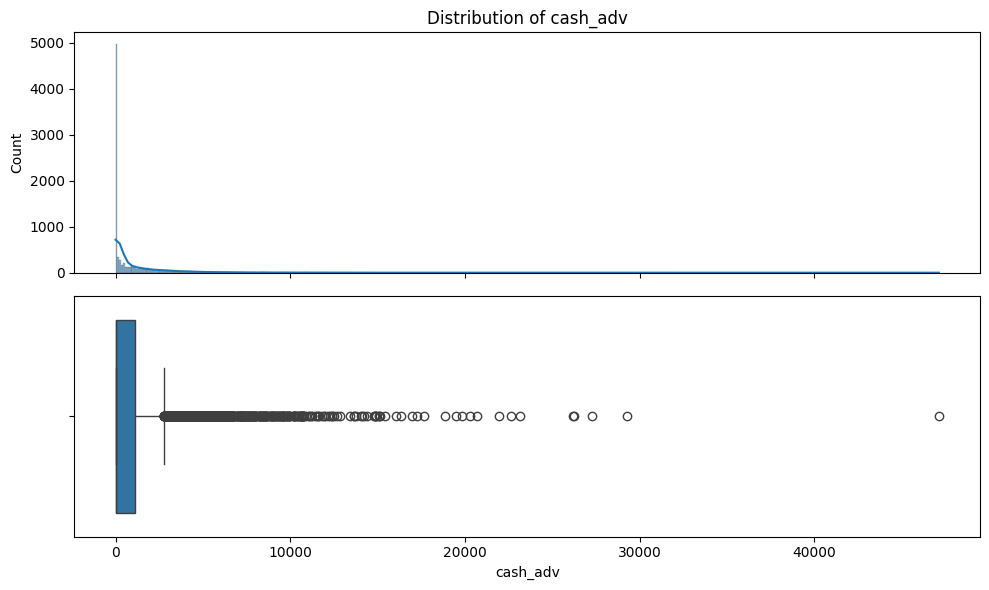

----------------------------------------------------------------------------------------------------
Feature Name: purch_freq

Descrtiptive Statistics:
count    8950.000000
mean        0.490351
std         0.401371
min         0.000000
25%         0.083333
50%         0.500000
75%         0.916667
max         1.000000
Name: purch_freq, dtype: float64

Skewness: 0.06


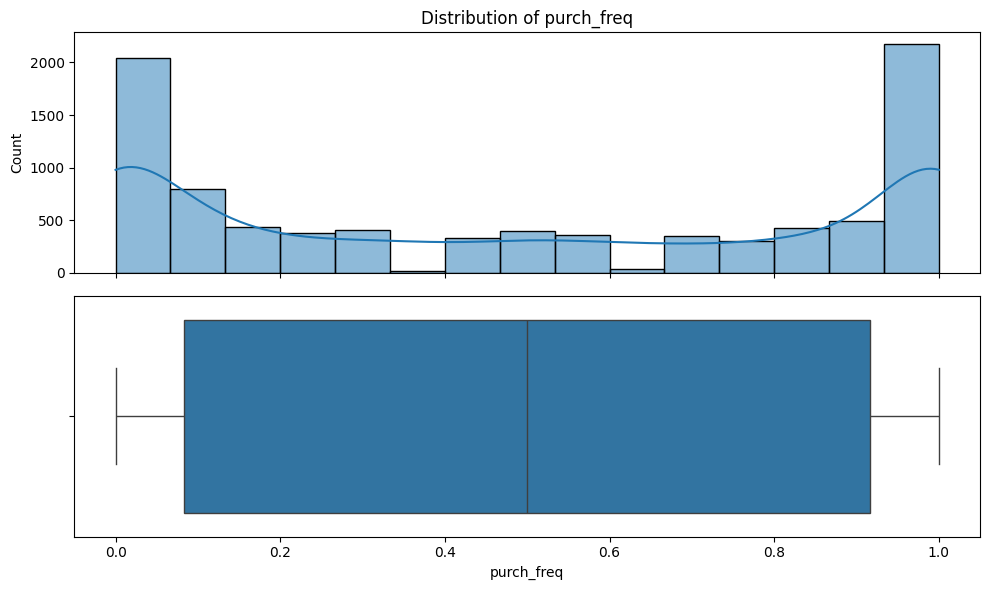

----------------------------------------------------------------------------------------------------
Feature Name: oneoff_freq

Descrtiptive Statistics:
count    8950.000000
mean        0.202458
std         0.298336
min         0.000000
25%         0.000000
50%         0.083333
75%         0.300000
max         1.000000
Name: oneoff_freq, dtype: float64

Skewness: 1.54


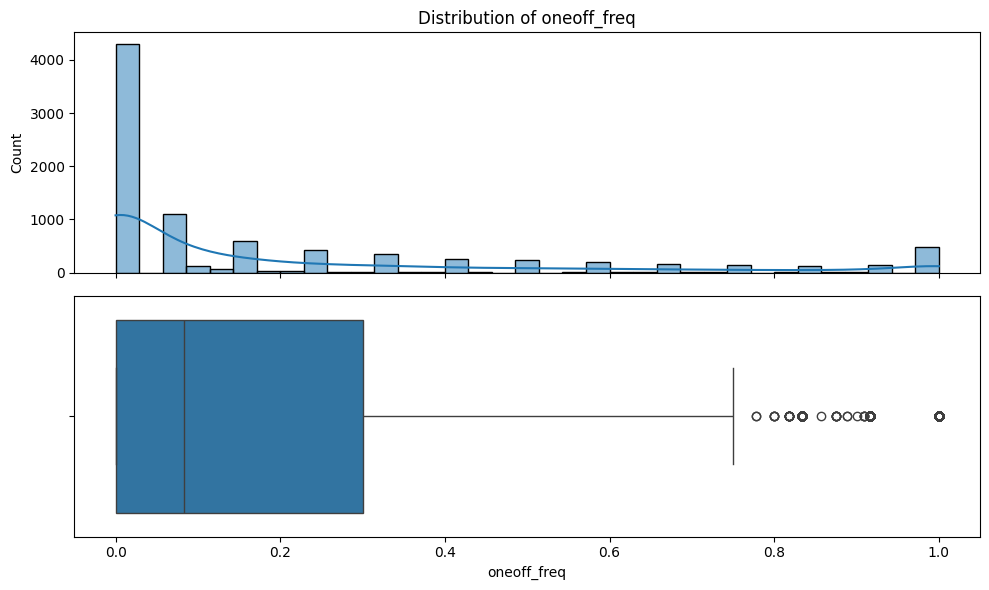

----------------------------------------------------------------------------------------------------
Feature Name: install_freq

Descrtiptive Statistics:
count    8950.000000
mean        0.364437
std         0.397448
min         0.000000
25%         0.000000
50%         0.166667
75%         0.750000
max         1.000000
Name: install_freq, dtype: float64

Skewness: 0.51


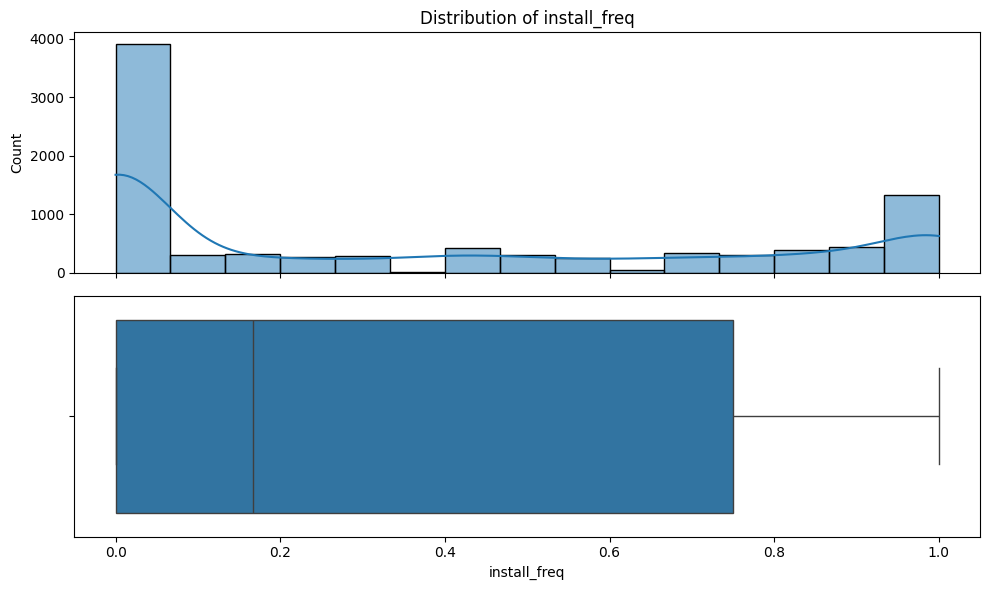

----------------------------------------------------------------------------------------------------
Feature Name: cash_freq

Descrtiptive Statistics:
count    8950.000000
mean        0.135144
std         0.200121
min         0.000000
25%         0.000000
50%         0.000000
75%         0.222222
max         1.500000
Name: cash_freq, dtype: float64

Skewness: 1.83


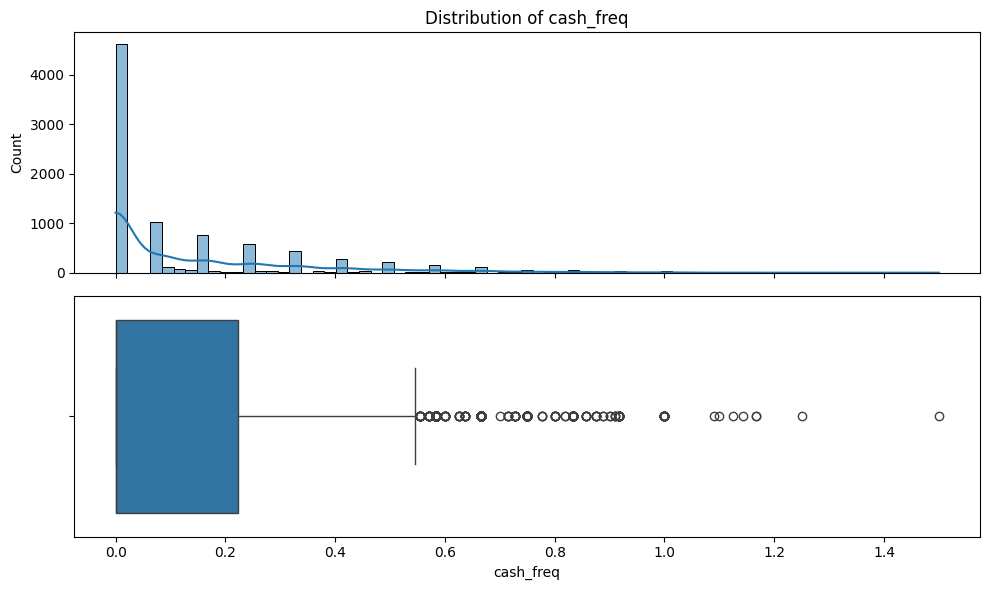

----------------------------------------------------------------------------------------------------
Feature Name: cash_tx

Descrtiptive Statistics:
count    8950.000000
mean        3.248827
std         6.824647
min         0.000000
25%         0.000000
50%         0.000000
75%         4.000000
max       123.000000
Name: cash_tx, dtype: float64

Skewness: 5.72


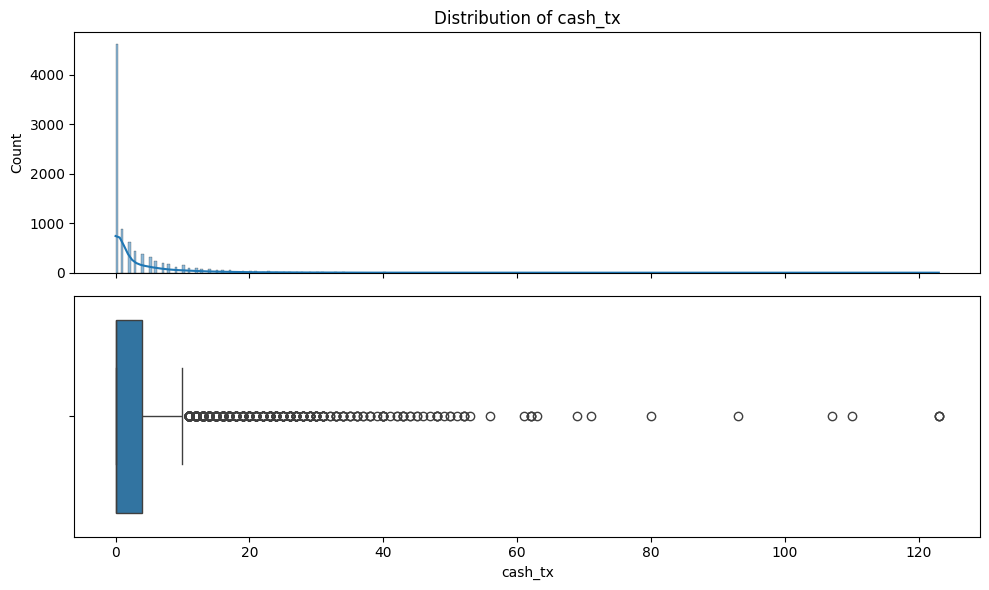

----------------------------------------------------------------------------------------------------
Feature Name: purch_tx

Descrtiptive Statistics:
count    8950.000000
mean       14.709832
std        24.857649
min         0.000000
25%         1.000000
50%         7.000000
75%        17.000000
max       358.000000
Name: purch_tx, dtype: float64

Skewness: 4.63


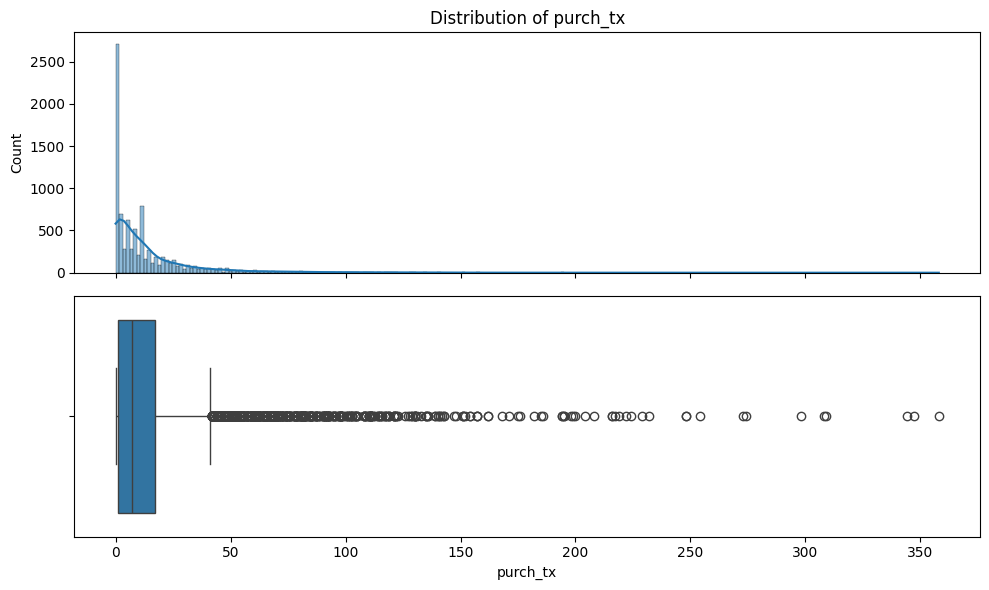

----------------------------------------------------------------------------------------------------
Feature Name: credit

Descrtiptive Statistics:
count     8949.000000
mean      4494.449450
std       3638.815725
min         50.000000
25%       1600.000000
50%       3000.000000
75%       6500.000000
max      30000.000000
Name: credit, dtype: float64

Skewness: 1.52


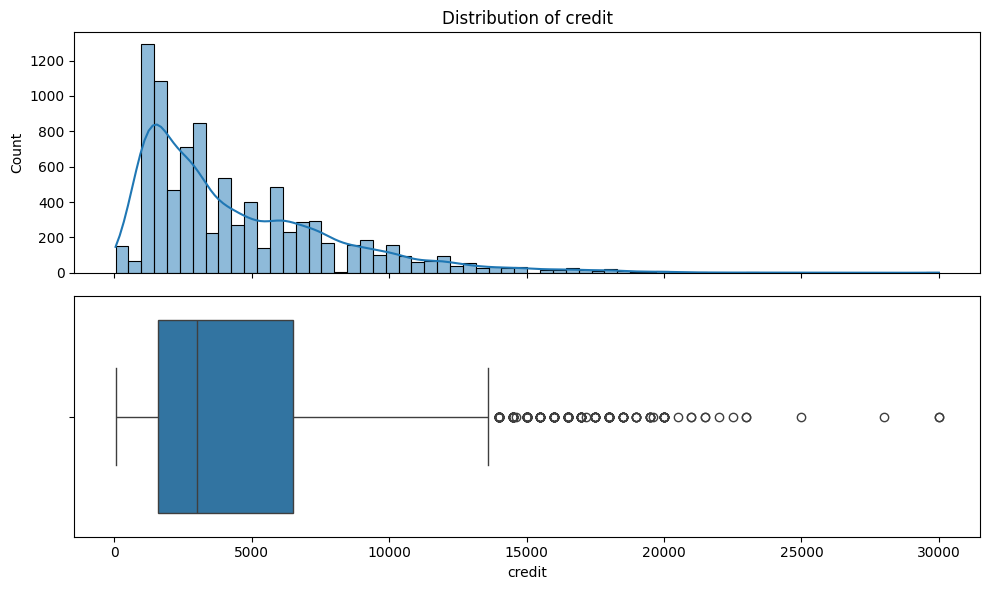

----------------------------------------------------------------------------------------------------
Feature Name: pay_amt

Descrtiptive Statistics:
count     8950.000000
mean      1733.143852
std       2895.063757
min          0.000000
25%        383.276166
50%        856.901546
75%       1901.134317
max      50721.483360
Name: pay_amt, dtype: float64

Skewness: 5.91


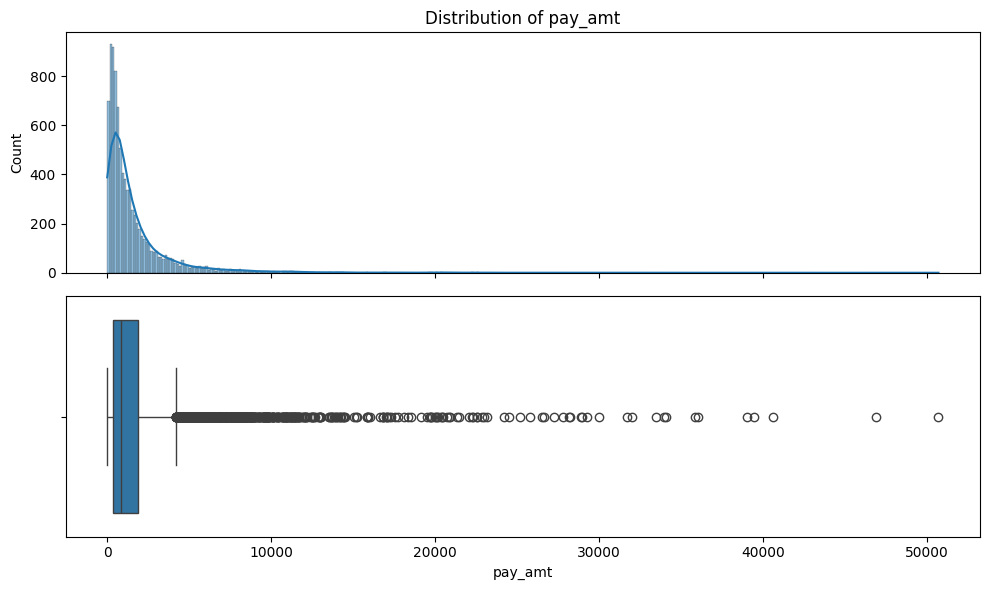

----------------------------------------------------------------------------------------------------
Feature Name: min_pay

Descrtiptive Statistics:
count     8637.000000
mean       864.206542
std       2372.446607
min          0.019163
25%        169.123707
50%        312.343947
75%        825.485459
max      76406.207520
Name: min_pay, dtype: float64

Skewness: 13.62


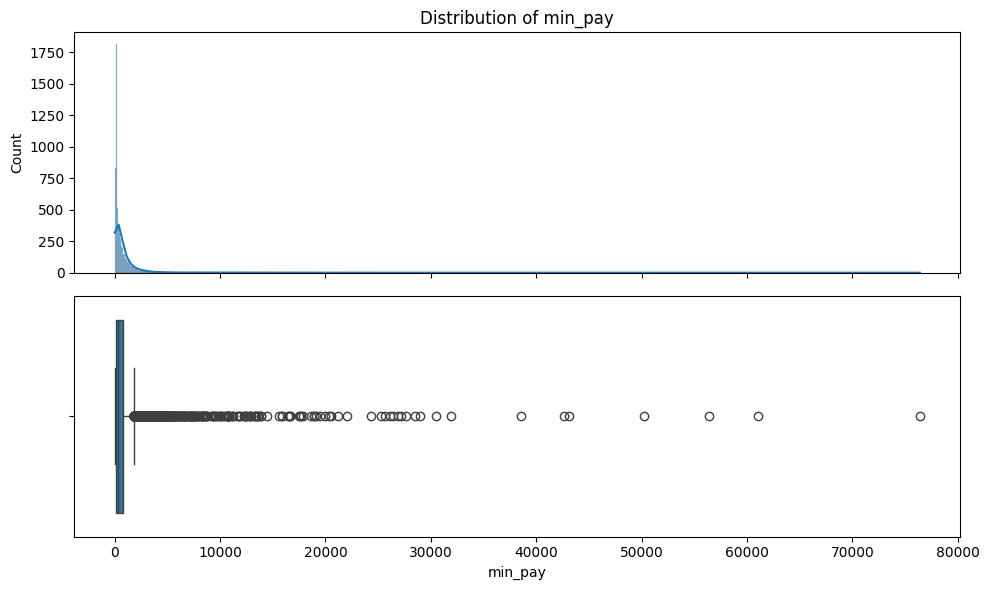

----------------------------------------------------------------------------------------------------
Feature Name: full_pay

Descrtiptive Statistics:
count    8950.000000
mean        0.153715
std         0.292499
min         0.000000
25%         0.000000
50%         0.000000
75%         0.142857
max         1.000000
Name: full_pay, dtype: float64

Skewness: 1.94


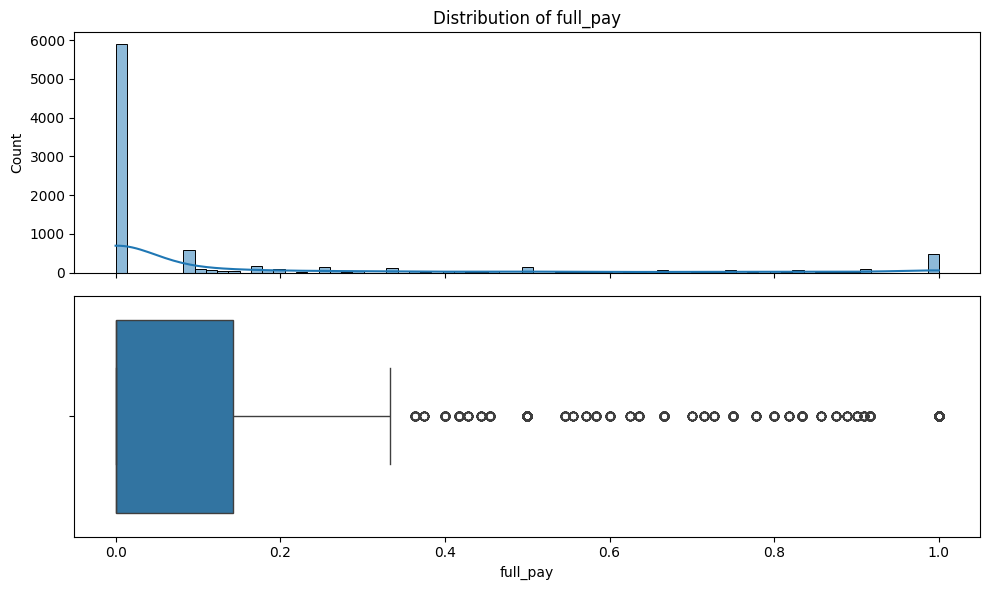

In [18]:
for i in df.columns.drop(["cust_id", "months"]):
    num_univariate(df, i)

In [19]:
def cat_univariate(df, col):
    print("-"*100)
    print(f"Feature Name: {col}")

    print("\nValue Counts:")
    print(df[col].value_counts())
    print(f"\nMissing Values: {df[col].isnull().sum()}")

    fig, ax = plt.subplots(1,2, figsize=(10,6))

    sns.countplot(df, x=col, ax=ax[0])
    ax[0].set_title(f"Count Plot of {col}")
    ax[0].set_xlabel(col)
    ax[0].set_ylabel("Count")

    df[col].value_counts().plot.pie(autopct="%1.1f%%", startangle=90, ax=ax[1])
    ax[1].set_ylabel("")
    ax[1].set_title(f"Pie chart of {col}")

    plt.tight_layout()
    plt.show()

----------------------------------------------------------------------------------------------------
Feature Name: months

Value Counts:
months
12    7584
11     365
10     236
6      204
8      196
7      190
9      175
Name: count, dtype: int64

Missing Values: 0


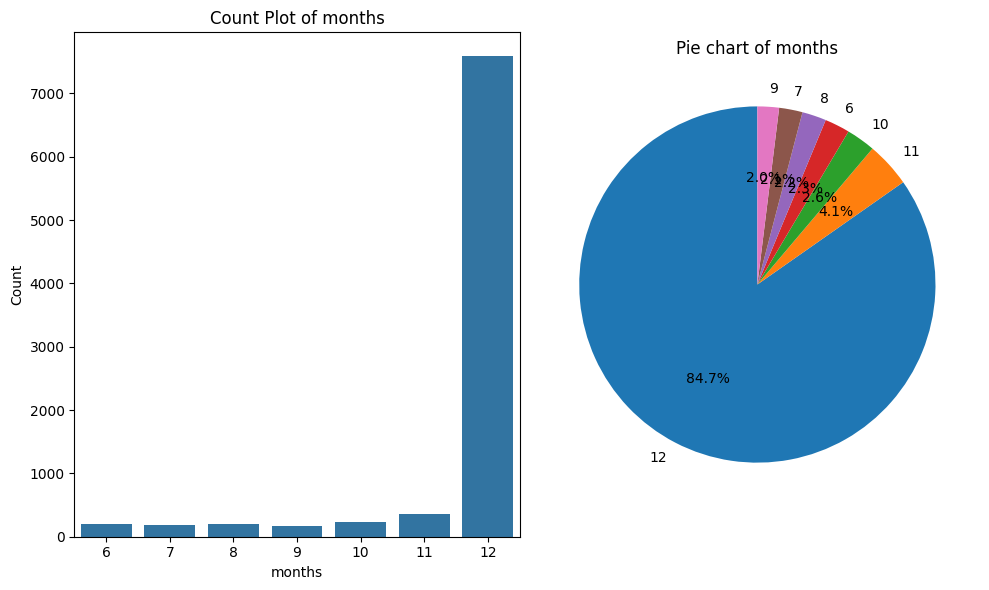

In [20]:
cat_univariate(df, "months")

In [21]:
# sns.pairplot(df, hue="months")

## 3. Data Preprocessing

In [22]:
df.head()

,cust_id,balance,bal_freq,purch,oneoff,install,cash_adv,purch_freq,oneoff_freq,install_freq,cash_freq,cash_tx,purch_tx,credit,pay_amt,min_pay,full_pay,months
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [23]:
# removing unnecessary column as it is not required for model training.
df.drop("cust_id", axis=1, inplace=True)

In [24]:
def fill_na(df , column) : 
    df[column] =   df[column].fillna(df[column].median())

fill_na(df , 'credit')
fill_na(df , 'min_pay')

df.isna().sum()

balance         0
bal_freq        0
purch           0
oneoff          0
install         0
cash_adv        0
purch_freq      0
oneoff_freq     0
install_freq    0
cash_freq       0
cash_tx         0
purch_tx        0
credit          0
pay_amt         0
min_pay         0
full_pay        0
months          0
dtype: int64

In [25]:
scaler = StandardScaler()

X = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
X

,balance,bal_freq,purch,oneoff,install,cash_adv,purch_freq,oneoff_freq,install_freq,cash_freq,cash_tx,purch_tx,credit,pay_amt,min_pay,full_pay,months
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.360680
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.360680
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.360680
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.360680
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.360680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,-0.737950,0.518084,-0.333293,-0.356934,-0.132643,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960378,-0.486217,-0.341250,1.183951,-4.122768
8946,-0.742423,0.518084,-0.329136,-0.356934,-0.122823,-0.466786,1.269843,-0.678661,1.179833,-0.675349,-0.476070,-0.350408,-0.960378,-0.503396,-0.228307,-0.525551,-4.122768
8947,-0.740398,-0.185477,-0.401965,-0.356934,-0.294893,-0.466786,0.854576,-0.678661,0.760469,-0.675349,-0.476070,-0.390639,-0.960378,-0.570615,-0.326875,0.329200,-4.122768
8948,-0.745174,-0.185477,-0.469552,-0.356934,-0.454576,-0.449352,-1.221758,-0.678661,-0.916995,0.157527,-0.182998,-0.591796,-1.097800,-0.580536,-0.338305,0.329200,-4.122768


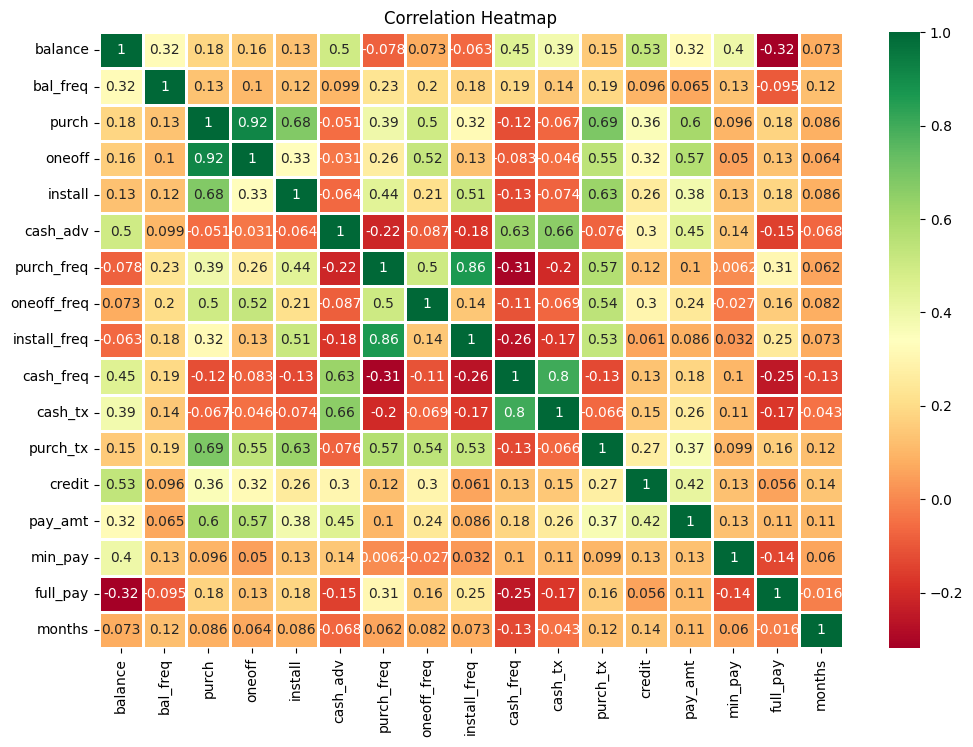

In [26]:
# correlation threshold 0.9

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="RdYlGn", linewidths=1, linecolor="white")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
pca = PCA()
pca.fit(X)

,n_components,None
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


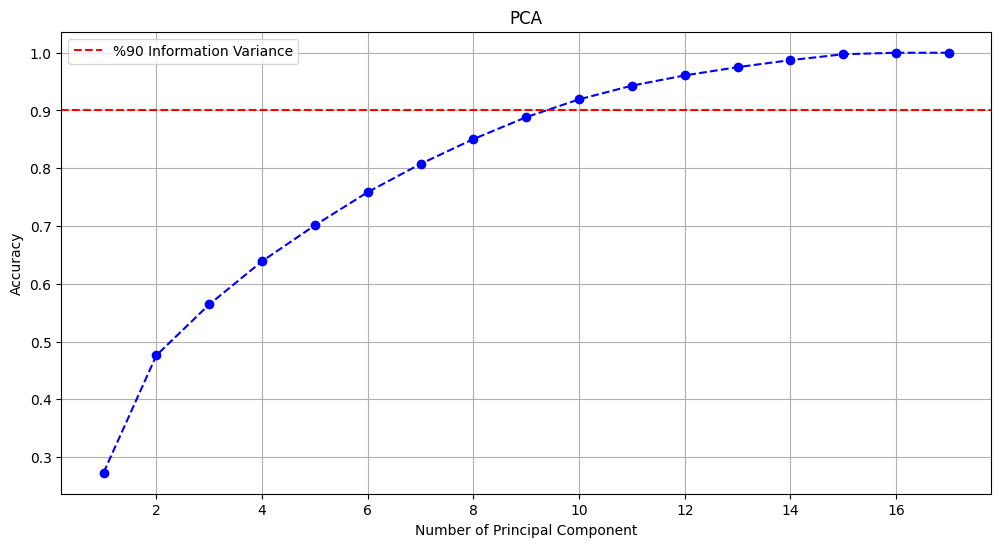

In [28]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12, 6))
plt.plot(range(1 , len(cumulative_variance) + 1 ) , cumulative_variance , marker = 'o' , linestyle = '--' , color = 'b')
plt.axhline(y = 0.9 , linestyle = '--' , label = '%90 Information Variance' , color = 'r')
plt.title('PCA')
plt.xlabel('Number of Principal Component')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()

In [29]:
pca = PCA(n_components=10)
pca_trf = pca.fit_transform(X)

pca_X = pd.DataFrame(pca_trf, columns = ['PCA1' , 'PCA2' , 'PCA3' , 'PCA4' , 'PCA5', 'PCA6' , 'PCA7' , 'PCA8' , 'PCA9' , 'PCA10'])
pca_X

,PCA1,PCA2,PCA3,PCA4,PCA5,PCA6,PCA7,PCA8,PCA9,PCA10
0,-1.683649,-1.072241,-0.475660,0.679928,-0.043195,-0.068069,-0.822155,-0.018952,0.118336,0.078196
1,-1.134085,2.509150,-0.602216,-0.109542,-0.662638,1.102255,0.384282,0.176154,0.674472,0.777929
2,0.969395,-0.383577,-0.090970,1.238359,2.166584,0.320185,1.542496,-0.229364,-0.867803,0.001744
3,-0.888220,0.004648,-1.499800,1.075271,-0.225828,0.171540,0.236644,-0.690410,-0.064245,-0.393690
4,-1.600021,-0.683795,-0.347927,1.013642,0.453816,-0.077004,-0.698278,0.245311,0.578032,0.122073
...,...,...,...,...,...,...,...,...,...,...
8945,-0.362572,-2.013437,0.975609,-2.742418,-0.124714,-2.673427,1.561393,0.277404,1.371131,0.845167
8946,-0.580810,-1.675663,1.222354,-1.980537,0.073504,-3.312539,1.068590,-0.639929,0.940227,1.245566
8947,-0.928985,-1.808048,0.458242,-2.296301,-0.234615,-2.980784,1.403265,-0.292832,0.810029,0.830136
8948,-2.337845,-0.653611,-0.982831,-1.847692,0.070276,-3.179484,0.973534,0.230863,1.205675,-0.268663


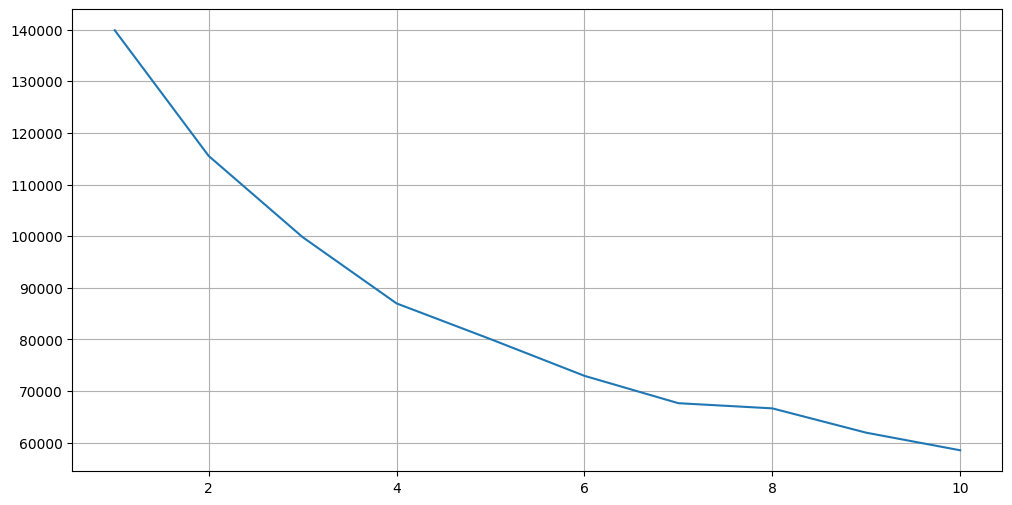

In [30]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init="k-means++")
    kmeans.fit(pca_X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(range(1, 11), wcss)
plt.grid(True)

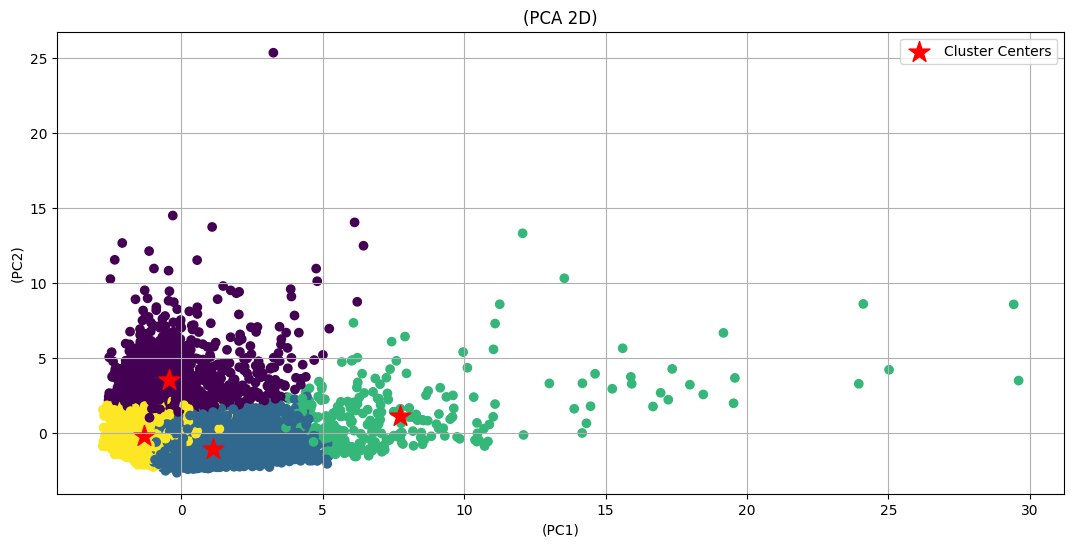

In [33]:
ideal_c = 4

kmeans = KMeans(n_clusters = ideal_c , init = 'k-means++' , random_state = 42)
clusters = kmeans.fit_predict(pca_X)

plt.figure(figsize = (13 , 6))
plt.scatter(pca_X.iloc[: ,0 ] , pca_X.iloc[:, 1] , c = clusters ,cmap = 'viridis')
plt.scatter(kmeans.cluster_centers_[:, 0] , kmeans.cluster_centers_[:, 1] , s = 250 , marker = '*' , label = 'Cluster Centers' , c= 'r')
plt.title('(PCA 2D)')
plt.xlabel('(PC1)')
plt.ylabel('(PC2)')
plt.legend()
plt.grid(True)
plt.show()

In [38]:

from sklearn.cluster import KMeans

ideal_c = 4

kmeans = KMeans(n_clusters=ideal_c, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(pca_X)

# Create dataframe for plotting
plot_df = pca_X.copy()
plot_df["Cluster"] = clusters

# 3D scatter plot
fig = px.scatter_3d(
    plot_df,
    x=plot_df.iloc[:,0],
    y=plot_df.iloc[:,1],
    z=plot_df.iloc[:,2],
    color="Cluster",
    title="KMeans Clusters (PCA 3D)",
    color_continuous_scale="viridis"
)

# Add cluster centers
fig.add_trace(
    go.Scatter3d(
        x=kmeans.cluster_centers_[:,0],
        y=kmeans.cluster_centers_[:,1],
        z=kmeans.cluster_centers_[:,2],
        mode="markers",
        marker=dict(size=10, color="red", symbol="diamond"),
        name="Cluster Centers"
    )
)

fig.show()